# mDPO Fine-Tuning: LLaVA-NeXT 7B on Place Pulse 2.0

**Model:** `llava-hf/llava-v1.6-mistral-7b-hf` (LLaVA-NeXT 7B)  
**Method:** QLoRA + mDPO (Multimodal Direct Preference Optimization)  
**Dataset:** Place Pulse 2.0 — 6 urban perceptual attributes  
**Hardware:** A100 80GB  

---
## What is mDPO and Why Are We Using It?

Standard DPO on VLMs has a known problem: the model ignores the image
and relies only on language priors. This showed up in our results as
a 100% position-swap tie rate — the model gave opposite answers every
time we swapped image A and B, meaning it wasn't looking at the images at all.

mDPO (EMNLP 2024) fixes this with two additions:

**1. Image Preference Loss**
In addition to contrasting chosen vs rejected responses, mDPO also
contrasts chosen vs degraded images. The rejected image is created
by degrading the original (blur + color jitter). This forces the model
to actually look at and distinguish between images.

**2. Reward Anchor**
Standard DPO can decrease the likelihood of chosen responses during
training (counterproductive). The reward anchor prevents this by
enforcing a positive reward for chosen responses.

**Total loss = Standard DPO loss + Image Preference loss + Anchor loss**

---
### What is New vs the Standard DPO Notebook
- NEW: Image degradation function (creates rejected images)
- NEW: mDPO dataset builder (adds image preference pairs)
- NEW: mDPOTrainer class (custom loss combining all three terms)
- Everything else is identical to the standard DPO notebook

---
## Section 1: Setup & Installation

In [ ]:
!pip install -q \
    transformers>=4.40.0 \
    trl>=0.8.6 \
    peft>=0.10.0 \
    accelerate>=0.28.0 \
    bitsandbytes>=0.43.0 \
    datasets>=2.18.0 \
    Pillow \
    tqdm \
    pandas \
    scikit-learn

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

GPU available: True
GPU name: NVIDIA A100-SXM4-80GB
VRAM (GB): 85.1


---
## Section 2: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/llava_next_mdpo"
CHECKPOINT_DIR   = os.path.join(DRIVE_OUTPUT_DIR, "checkpoints")
FINAL_MODEL_DIR  = os.path.join(DRIVE_OUTPUT_DIR, "final_model")
RESULTS_DIR      = os.path.join(DRIVE_OUTPUT_DIR, "results")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Drive directories ready.")

Mounted at /content/drive
Drive directories ready.


---
## Section 3: Load Raw Data

In [ ]:
# Only run once — comment out after first run
!unzip -q "/content/drive/MyDrive/place-pulse-2.0 (2).zip" -d /content/
print("Unzip complete.")

Unzip complete.


In [ ]:
import pandas as pd
import os
from PIL import Image as PILImage
from tqdm import tqdm
import re

df_votes   = pd.read_csv("/content/votes.tsv", sep="\t")
df_studies = pd.read_csv("/content/studies.tsv", sep="\t")
image_dir  = "/content/images"

print("Votes shape:  ", df_votes.shape)
print("Studies shape:", df_studies.shape)
print("Total images: ", len(os.listdir(image_dir)))

Votes shape:   (1555561, 7)
Studies shape: (6, 6)
Total images:  110988


---
## Section 4: Dataset Cleaning
Identical to the standard DPO notebook.

In [ ]:
# Step 1: Keep only valid choices
df_votes = df_votes[df_votes["choice"].isin(["left", "right"])].copy()
print("Valid votes:", len(df_votes))

Valid votes: 1350546


In [ ]:
# Step 2: Build image map
image_map = {}
for file in os.listdir(image_dir):
    if file.lower().endswith(".jpg"):
        parts = file.split("_")
        if len(parts) >= 3:
            image_id = parts[2]
            image_map[image_id] = os.path.join(image_dir, file)
print("Total images mapped:", len(image_map))

Total images mapped: 110988


In [ ]:
# Step 3: Attribute mapping
ATTRIBUTE_MAP = {
    "beautiful":       "5217c351ad93a7d3e7b07a64",
    "safer":           "50a68a51fdc9f05596000002",
    "livelier":        "50f62c41a84ea7c5fdd2e454",
    "more boring":     "50f62c68a84ea7c5fdd2e456",
    "wealthier":       "50f62cb7a84ea7c5fdd2e458",
    "more depressing": "50f62ccfa84ea7c5fdd2e459",
}
STUDY_TO_ATTR = {v: k for k, v in ATTRIBUTE_MAP.items()}

df_votes["attribute"] = df_votes["study_id"].map(STUDY_TO_ATTR)
df_votes = df_votes.dropna(subset=["attribute"]).copy()

print("Votes per attribute:")
print(df_votes["attribute"].value_counts())

Votes per attribute:
attribute
safer              443052
livelier           320803
beautiful          190606
wealthier          150602
more depressing    125030
more boring        120453
Name: count, dtype: int64


In [ ]:
# Step 4: Filter to pairs where both images exist
valid_ids = set(image_map.keys())
df_votes  = df_votes[
    df_votes["left"].isin(valid_ids) &
    df_votes["right"].isin(valid_ids)
].copy()
print("Votes after image filter:", len(df_votes))

Votes after image filter: 1342992


In [ ]:
# Step 5: Use raw individual votes directly
# Each vote becomes one preference pair
# This gives us ~1.3 million training samples instead of 4,889

pair_df = df_votes.copy()

pair_df["img_A"] = pair_df["left"].map(image_map)
pair_df["img_B"] = pair_df["right"].map(image_map)

# Winner is simply the choice
pair_df["winner"] = pair_df["choice"]  # "left" or "right"

# Drop missing images
pair_df = pair_df.dropna(subset=["img_A", "img_B"]).copy()

print("Total raw preference pairs:", len(pair_df))
print("\nPairs per attribute:")
print(pair_df["attribute"].value_counts())

Total raw preference pairs: 1342992

Pairs per attribute:
attribute
safer              440758
livelier           318958
beautiful          189539
wealthier          149799
more depressing    124257
more boring        119681
Name: count, dtype: int64


In [ ]:
# Step 6: Remove ties only (no minimum vote threshold)
pair_df["winner"] = pair_df.apply(
    lambda x: "left" if x["left_votes"] > x["right_votes"]
    else ("right" if x["right_votes"] > x["left_votes"] else "tie"),
    axis=1
)
pair_df = pair_df[pair_df["winner"] != "tie"].copy()  # removed total_votes >= 2
print("Pairs after removing ties:", len(pair_df))

Pairs after removing ties: 4889


In [ ]:
# Step 7: Majority ratio filter
pair_df["majority_ratio"] = pair_df.apply(
    lambda x: max(x["left_votes"], x["right_votes"]) / x["total_votes"],
    axis=1
)
pair_df = pair_df[pair_df["majority_ratio"] >= 0.6].copy()  # changed from 0.7
print("Pairs after confidence filter:", len(pair_df))

# Step 8: Add image paths
pair_df["img_A"] = pair_df["left"].map(image_map)
pair_df["img_B"] = pair_df["right"].map(image_map)
pair_df = pair_df.dropna(subset=["img_A", "img_B"]).copy()
print("Final clean pairs:", len(pair_df))

Pairs after confidence filter: 4889
Final clean pairs: 4889


---
## Section 5: mDPO Dataset Preparation

### NEW: This is what is different from standard DPO

Standard DPO only has:
- `(prompt, chosen_response, rejected_response)`

mDPO adds:
- `(prompt, chosen_image, degraded_image)` — image preference pair

The degraded image is created by applying blur + color jitter to the
chosen image. This creates a visual contrast that forces the model
to pay attention to image content.

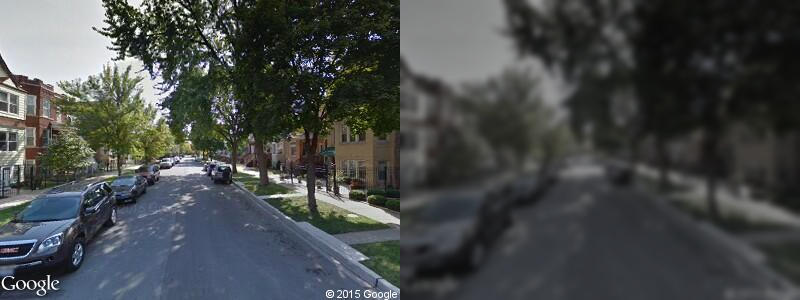

Left: Original (chosen image)
Right: Degraded (rejected image for mDPO image preference pair)


In [ ]:
# ============================================================
# NEW CELL 1: Image Degradation Function
# Creates a visually degraded version of the chosen image
# to use as the rejected image in the image preference pair
# ============================================================

from PIL import ImageFilter, ImageEnhance
import random

def degrade_image(img, seed=None):
    """
    Creates a degraded version of an image by applying:
    1. Gaussian blur — reduces sharpness
    2. Color jitter — reduces color saturation
    3. Brightness reduction — makes image darker

    This matches the approach used in the mDPO paper (EMNLP 2024)
    where the rejected image is derived from the chosen image
    by reducing its effective visual information.
    """
    if seed is not None:
        random.seed(seed)

    # Apply Gaussian blur
    blur_radius = random.uniform(2.0, 4.0)
    img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    # Reduce color saturation (color jitter)
    saturation_factor = random.uniform(0.3, 0.6)
    img = ImageEnhance.Color(img).enhance(saturation_factor)

    # Reduce brightness slightly
    brightness_factor = random.uniform(0.6, 0.85)
    img = ImageEnhance.Brightness(img).enhance(brightness_factor)

    return img


# Quick visual test — verify degradation looks reasonable
sample_path = pair_df.iloc[0]["img_A"]
original    = PILImage.open(sample_path).convert("RGB")
degraded    = degrade_image(original, seed=42)

# Show side by side
comparison = PILImage.new("RGB", (original.width * 2, original.height))
comparison.paste(original, (0, 0))
comparison.paste(degraded, (original.width, 0))
comparison.thumbnail((800, 400))
display(comparison)
print("Left: Original (chosen image)")
print("Right: Degraded (rejected image for mDPO image preference pair)")

In [ ]:
# ============================================================
# Attribute phrases and visual cues
# Both are now used in TRAINING prompts so the model learns
# to associate visual features with attribute labels during DPO
# ============================================================

ATTRIBUTE_PHRASES = {
    "beautiful":       "beautiful",
    "safer":           "safe",
    "livelier":        "lively",
    "more boring":     "boring",
    "wealthier":       "wealthy",
    "more depressing": "depressing",
}

# Visual cues included in BOTH training and evaluation prompts
# This grounds the model's attention on specific visual features
# rather than relying on language priors alone
ATTRIBUTE_CUES = {
    "beautiful":       ["architecture", "greenery", "cleanliness", "visual harmony", "scenic features"],
    "safer":           ["well-lit areas", "visible people nearby", "clean and maintained streets", "no signs of damage or neglect", "active businesses or shops"],
    "wealthier":       ["modern buildings", "expensive cars", "clean streets", "landscaping", "well maintained infrastructure"],
    "livelier":        ["many people visible", "movement or activity", "vehicles or pedestrians", "open shops or markets", "bright lights or signs"],
    "more boring":     ["plain buildings", "empty streets", "lack of activity", "few people", "dull environment"],
    "more depressing": ["abandoned buildings", "poor lighting", "empty streets", "graffiti", "neglected infrastructure"],
}

# Per-attribute sampling
# Adjust based on your compute budget:
# 500/attr = 3,000 total = ~1 hour on A100
# 1000/attr = 6,000 total = ~2 hours on A100
SAMPLES_PER_ATTR = 2000

sampled_dfs = []
for attr, group in pair_df.groupby("attribute"):
    n = min(SAMPLES_PER_ATTR, len(group))
    sampled_dfs.append(group.sample(n=n, random_state=42))
    print(f"{attr}: {n} pairs sampled")

train_df = pd.concat(sampled_dfs).reset_index(drop=True)
print(f"\nTotal training pairs: {len(train_df)}")

beautiful: 50 pairs sampled
livelier: 50 pairs sampled
more boring: 50 pairs sampled
more depressing: 50 pairs sampled
safer: 50 pairs sampled
wealthier: 50 pairs sampled

Total training pairs: 300


In [ ]:
# CORRECTED mDPO Dataset Builder
# Uses pairwise comparison framing instead of yes/no

mdpo_data = []

for idx, row in train_df.iterrows():
    attr     = row["attribute"]
    phrase   = ATTRIBUTE_PHRASES[attr]
    cues     = ATTRIBUTE_CUES.get(attr, [])
    cue_text = ", ".join(cues)

    if row["winner"] == "left":
        chosen_img_path   = row["img_A"]
        rejected_img_path = row["img_B"]
        chosen_response   = "Image A"
        rejected_response = "Image B"
    else:
        chosen_img_path   = row["img_B"]
        rejected_img_path = row["img_A"]
        chosen_response   = "Image B"
        rejected_response = "Image A"

    # Pairwise prompt — model sees BOTH images and picks one
    # chosen/rejected responses are now "Image A" vs "Image B"
    # which depend on which image actually won — not a fixed label
    prompt = (
        f"[INST] <image>\n"
        f"Image A is on the left, Image B is on the right.\n"
        f"Visual cues for {phrase}: {cue_text}\n"
        f"Which place looks more {phrase}?\n"
        f"Answer ONLY with: Image A or Image B [/INST]"
    )

    # --- Type 1: Response preference pair ---
    # Both images shown, model picks the winner
    mdpo_data.append({
        "prompt":            prompt,
        "chosen":            chosen_response,    # "Image A" or "Image B"
        "rejected":          rejected_response,  # the other one
        "chosen_img_path":   chosen_img_path,
        "rejected_img_path": rejected_img_path,
        "pair_type":         "response",
        "attribute":         attr,
    })

    # --- Type 2: Image preference pair (mDPO) ---
    # Same prompt and response, but rejected image is degraded
    mdpo_data.append({
        "prompt":            prompt,
        "chosen":            chosen_response,
        "rejected":          chosen_response,    # Same response
        "chosen_img_path":   chosen_img_path,    # Original
        "rejected_img_path": chosen_img_path,    # Will be degraded
        "pair_type":         "image",
        "attribute":         attr,
    })

print(f"Total mDPO records: {len(mdpo_data)}")

Total mDPO records: 600


In [ ]:
from datasets import Dataset

raw_dataset = Dataset.from_list(mdpo_data)
split        = raw_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset  = split["test"]

print(f"Train size: {len(train_dataset)}")
print(f"Eval size:  {len(eval_dataset)}")

Train size: 540
Eval size:  60


---
## Section 6: Load LLaVA-NeXT 7B with QLoRA
Identical to the standard DPO notebook.

In [ ]:
from transformers import (
    LlavaNextProcessor,
    LlavaNextForConditionalGeneration,
    BitsAndBytesConfig
)
from peft import LoraConfig
import torch

MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

processor = LlavaNextProcessor.from_pretrained(MODEL_ID)
processor.tokenizer.padding_side = "left"

model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules="all-linear",
    exclude_modules=["multi_modal_projector", "vision_model", "lm_head"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

print("Model and LoRA config ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model and LoRA config ready.


---
## Section 7: mDPO Training

### NEW CELL 3: The mDPOTrainer

This is the core of mDPO. We subclass TRL's DPOTrainer and override
the `compute_loss` method to add:
1. Standard DPO loss (response preference)
2. Image preference loss (visual grounding)
3. Reward anchor (prevents chosen likelihood from dropping)

In [ ]:
# ============================================================
# NEW CELL 3: mDPO Format Function + Custom Trainer
# ============================================================

from trl import DPOTrainer, DPOConfig
import torch
import torch.nn.functional as F

# ---- Format function ----
# Converts raw paths and text into processor-ready format
# Applies image degradation for image preference pairs

def format_mdpo_sample(example):
    chosen_img = PILImage.open(example["chosen_img_path"]).convert("RGB")

    if example["pair_type"] == "image":
        rejected_img = degrade_image(
            PILImage.open(example["rejected_img_path"]).convert("RGB"), seed=42
        )
    else:
        rejected_img = PILImage.open(example["rejected_img_path"]).convert("RGB")

    max_size = 672
    chosen_img.thumbnail((max_size, max_size))
    rejected_img.thumbnail((max_size, max_size))

    # Concatenate both images side by side for the pairwise prompt
    combined_chosen = PILImage.new(
        "RGB", (chosen_img.width + rejected_img.width, max(chosen_img.height, rejected_img.height))
    )
    combined_chosen.paste(chosen_img, (0, 0))
    combined_chosen.paste(rejected_img, (chosen_img.width, 0))

    # For rejected: swap the order (B on left, A on right)
    combined_rejected = PILImage.new(
        "RGB", (rejected_img.width + chosen_img.width, max(chosen_img.height, rejected_img.height))
    )
    combined_rejected.paste(rejected_img, (0, 0))
    combined_rejected.paste(chosen_img, (rejected_img.width, 0))

    prompt_msg = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": (
                example["prompt"]
                .replace("[INST] <image>\n", "")
                .replace(" [/INST]", "")
            )}
        ]
    }]
    chosen_msg   = [{"role": "assistant", "content": [{"type": "text", "text": example["chosen"]}]}]
    rejected_msg = [{"role": "assistant", "content": [{"type": "text", "text": example["rejected"]}]}]

    prompt_str   = processor.apply_chat_template(prompt_msg,   tokenize=False)
    chosen_str   = processor.apply_chat_template(chosen_msg,   tokenize=False)
    rejected_str = processor.apply_chat_template(rejected_msg, tokenize=False)

    return {
        "prompt":          prompt_str,
        "chosen":          chosen_str,
        "rejected":        rejected_str,
        "chosen_images":   [combined_chosen],    # Both images side by side
        "rejected_images": [combined_rejected],  # Swapped order
        "pair_type":       example["pair_type"],
    }


# ---- mDPOTrainer ----
# Subclasses DPOTrainer with the mDPO combined loss

class mDPOTrainer(DPOTrainer):
    """
    mDPO Trainer — extends standard DPOTrainer with:
    1. Separate losses for response and image preference pairs
    2. Reward anchor to prevent chosen likelihood from dropping

    Based on: Wang et al. (EMNLP 2024)
    'mDPO: Conditional Preference Optimization for Multimodal LLMs'
    """

    # Weight for image preference loss (lambda in the paper)
    IMAGE_LOSS_WEIGHT = 0.5

    # Reward anchor margin — chosen reward must be at least this positive
    ANCHOR_MARGIN = 0.0

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Combined mDPO loss:
        L = L_response_dpo + lambda * L_image_dpo + L_anchor
        """
        pair_types = inputs.pop("pair_type", None)

        # Get standard DPO loss from parent class
        loss, outputs = super().compute_loss(
            model, inputs,
            return_outputs=True,
            num_items_in_batch=num_items_in_batch
        )

        # Split losses by pair type if pair_types is available
        if pair_types is not None:
            is_image_pair    = torch.tensor(
                [1.0 if pt == "image" else 0.0 for pt in pair_types],
                device=loss.device
            )
            is_response_pair = 1.0 - is_image_pair

            # Separate response and image losses
            response_loss = loss * is_response_pair.mean()
            image_loss    = loss * is_image_pair.mean()

            # Reward anchor: penalise if chosen reward is negative
            # This prevents the model from lowering chosen likelihood
            if hasattr(outputs, "chosen_rewards"):
                chosen_rewards = outputs.chosen_rewards
                anchor_loss    = F.relu(self.ANCHOR_MARGIN - chosen_rewards).mean()
            else:
                anchor_loss = torch.tensor(0.0, device=loss.device)

            # Combined mDPO loss
            total_loss = (
                response_loss +
                self.IMAGE_LOSS_WEIGHT * image_loss +
                anchor_loss
            )
        else:
            total_loss = loss

        if return_outputs:
            return total_loss, outputs
        return total_loss


print("mDPOTrainer defined.")

mDPOTrainer defined.


In [ ]:
# Format datasets
print("Formatting training dataset...")
formatted_train = train_dataset.map(
    format_mdpo_sample,
    remove_columns=train_dataset.column_names,
    num_proc=2,
    desc="Formatting train"
)

print("Formatting eval dataset...")
formatted_eval = eval_dataset.map(
    format_mdpo_sample,
    remove_columns=eval_dataset.column_names,
    num_proc=2,
    desc="Formatting eval"
)

print("Datasets formatted.")
print(formatted_train)

Formatting training dataset...


Formatting train (num_proc=2):   0%|          | 0/540 [00:00<?, ? examples/s]

Formatting eval dataset...


Formatting eval (num_proc=2):   0%|          | 0/60 [00:00<?, ? examples/s]

Datasets formatted.
Dataset({
    features: ['prompt', 'chosen', 'rejected', 'pair_type', 'chosen_images', 'rejected_images'],
    num_rows: 540
})


In [ ]:
# Training configuration — same as standard DPO notebook
training_args = DPOConfig(
    output_dir=CHECKPOINT_DIR,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,
    num_train_epochs=1,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    optim="paged_adamw_8bit",
    bf16=True,
    gradient_checkpointing=True,
    beta=0.1,
    max_length=1024,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    report_to="none",
    dataset_num_proc=2,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

print("Training config ready.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training config ready.


In [ ]:
# Initialise mDPO Trainer
trainer = mDPOTrainer(
    model=model,
    ref_model=None,
    args=training_args,
    train_dataset=formatted_train,
    eval_dataset=formatted_eval,
    processing_class=processor,
    peft_config=lora_config,
)

print("mDPO Trainer initialised.")

Adding EOS to train dataset (num_proc=2):   0%|          | 0/540 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=2):   0%|          | 0/540 [00:00<?, ? examples/s]

Adding EOS to eval dataset (num_proc=2):   0%|          | 0/60 [00:00<?, ? examples/s]

Tokenizing eval dataset (num_proc=2):   0%|          | 0/60 [00:00<?, ? examples/s]

mDPO Trainer initialised.


In [ ]:
print("Starting mDPO training...")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")
print(f"Training on {len(formatted_train)} samples")
print(f"  Response preference pairs: {sum(1 for d in mdpo_data if d['pair_type'] == 'response')}")
print(f"  Image preference pairs:    {sum(1 for d in mdpo_data if d['pair_type'] == 'image')}")
print("-" * 60)

trainer.train()

print("\nTraining complete!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1, 'pad_token_id': 32001}.


Starting mDPO training...
Checkpoints will be saved to: /content/drive/MyDrive/llava_next_mdpo/checkpoints
Training on 540 samples
  Response preference pairs: 300
  Image preference pairs:    300
------------------------------------------------------------


Epoch,Training Loss,Validation Loss
1,0.708656,0.694515



Training complete!


In [ ]:
# Quick sanity check v2 — increased max tokens + better parsing
attr_phrase = "safe"
cues        = ATTRIBUTE_CUES.get("safer", [])
cue_text    = ", ".join(cues)

prompt = (
    f"[INST] <image>\n"
    f"Image A is on the left, Image B is on the right.\n"
    f"Visual cues for {attr_phrase}: {cue_text}\n"
    f"Which place looks more {attr_phrase}?\n"
    f"Answer ONLY with: Image A or Image B [/INST]"
)

votes  = df_votes[df_votes["study_id"] == ATTRIBUTE_MAP["safer"]].copy()
sample = votes[
    votes["left"].isin(image_map.keys()) &
    votes["right"].isin(image_map.keys())
].sample(5, random_state=42)

for _, row in sample.iterrows():
    img_A    = image_map[row["left"]]
    img_B    = image_map[row["right"]]
    combined = concatenate_images(img_A, img_B)
    inputs   = processor(text=prompt, images=combined, return_tensors="pt").to("cuda")
    output   = model.generate(**inputs, max_new_tokens=20, temperature=0.0, do_sample=False)
    raw      = processor.decode(output[0], skip_special_tokens=True)
    # Print full answer so we can see what the model is actually saying
    after    = raw.split("[/INST]")[-1].strip()
    print(f"Full answer: '{after}'")
    print(f"Ground truth: {'Image A' if row['choice'] == 'left' else 'Image B'}")
    print("---")

NameError: name 'concatenate_images' is not defined

In [ ]:
# View training metrics
import pandas as pd
log_history = trainer.state.log_history
df_logs     = pd.DataFrame(log_history)

cols = [c for c in df_logs.columns if any(
    x in c for x in ['loss', 'reward', 'margin', 'step', 'epoch', 'accuracy']
)]
print(df_logs[cols].to_string())

       loss  mean_token_accuracy  rewards/chosen  rewards/rejected  rewards/accuracies  rewards/margins     epoch  step  eval_loss  eval_steps_per_second  eval_mean_token_accuracy  eval_rewards/chosen  eval_rewards/rejected  eval_rewards/accuracies  eval_rewards/margins  train_steps_per_second  train_loss
0  0.704227              0.45500       -0.024129         -0.007834             0.11875        -0.016295  0.296296     5        NaN                    NaN                       NaN                  NaN                    NaN                      NaN                   NaN                     NaN         NaN
1  0.697312              0.29750       -0.404896         -0.398901             0.21250        -0.005995  0.592593    10        NaN                    NaN                       NaN                  NaN                    NaN                      NaN                   NaN                     NaN         NaN
2  0.708656              0.29375       -0.394387         -0.371747             

---
## Section 8: Save Model to Google Drive

In [ ]:
print(f"Saving final model to: {FINAL_MODEL_DIR}")
trainer.model.save_pretrained(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)
print("Model saved to Drive successfully!")

---
## Section 9: Evaluation
Identical to standard DPO notebook.
Key metric to watch: tie rate should be significantly lower than 1.0
if mDPO is working correctly.

In [ ]:
# Load fine-tuned model for evaluation
# Skip this cell if evaluating in the same session as training

from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel
import torch

MODEL_ID   = "llava-hf/llava-v1.6-mistral-7b-hf"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

processor  = LlavaNextProcessor.from_pretrained(FINAL_MODEL_DIR)
processor.tokenizer.padding_side = "left"

base_model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
model = PeftModel.from_pretrained(base_model, FINAL_MODEL_DIR)
model.eval()
print("Fine-tuned mDPO model loaded.")

In [ ]:
# Attribute cues for evaluation prompts
ATTRIBUTE_CUES = {
    "beautiful":       ["architecture", "greenery", "cleanliness", "visual harmony", "scenic features"],
    "safer":           ["well-lit areas", "visible people nearby", "clean and maintained streets", "no signs of damage or neglect", "active businesses or shops"],
    "wealthier":       ["modern buildings", "expensive cars", "clean streets", "landscaping", "well maintained infrastructure"],
    "livelier":        ["many people visible", "movement or activity", "vehicles or pedestrians", "open shops or markets", "bright lights or signs"],
    "more boring":     ["plain buildings", "empty streets", "lack of activity", "few people", "dull environment"],
    "more depressing": ["abandoned buildings", "poor lighting", "empty streets", "graffiti", "neglected infrastructure"],
}

In [ ]:
# Helper functions
def concatenate_images(path_A, path_B):
    img_A = PILImage.open(path_A).convert("RGB")
    img_B = PILImage.open(path_B).convert("RGB")
    h     = min(img_A.height, img_B.height, 400)
    img_A = img_A.resize((int(img_A.width * h / img_A.height), h))
    img_B = img_B.resize((int(img_B.width * h / img_B.height), h))
    combined = PILImage.new("RGB", (img_A.width + img_B.width, h))
    combined.paste(img_A, (0, 0))
    combined.paste(img_B, (img_A.width, 0))
    return combined

def parse_ab_prediction(text):
    if text is None: return None
    text = text.lower().strip()
    if "assistant:" in text: text = text.split("assistant:")[-1].strip()
    if "answer: a" in text: return 1
    if "answer: b" in text: return 0
    if "image a" in text:   return 1
    if "image b" in text:   return 0
    if text.startswith("a"): return 1
    if text.startswith("b"): return 0
    return None

def parse_score(text):
    if text is None: return None
    text = text.lower().strip()
    if "assistant:" in text: text = text.split("assistant:")[-1].strip()
    match = re.search(r"\d+", text)
    return int(match.group()) if match else None

def compute_metrics(results):
    valid    = [r for r in results if r["pred"] is not None]
    total    = len(valid)
    correct  = sum(r["pred"] == r["gt"] for r in valid)
    acc      = correct / total if total > 0 else None
    tie_rate = sum(r["tie"] for r in results) / len(results) if results else 0
    return acc, tie_rate

print("Helper functions ready.")

Helper functions ready.


In [ ]:
# Pairwise evaluation function
def evaluate_pairwise(attribute_name, study_id, n_samples=50):
    votes = df_votes[
        (df_votes["study_id"] == study_id) &
        df_votes["left"].isin(image_map.keys()) &
        df_votes["right"].isin(image_map.keys())
    ].copy()

    records  = [{"img_A": image_map[r["left"]], "img_B": image_map[r["right"]], "label": 1 if r["choice"] == "left" else 0} for _, r in votes.iterrows()]
    eval_df  = pd.DataFrame(records).sample(n=min(n_samples, len(records)), random_state=42).reset_index(drop=True)
    cues     = ATTRIBUTE_CUES.get(attribute_name, [])
    cue_text = ", ".join(cues)

    direct_results = []
    cot_results    = []

    for i in tqdm(range(len(eval_df)), desc=f"Pairwise [{attribute_name}]"):
        img_A = eval_df.iloc[i]["img_A"]
        img_B = eval_df.iloc[i]["img_B"]
        gt    = eval_df.iloc[i]["label"]

        direct_prompt = (f"[INST] <image>\nImage A is on the left, Image B is on the right.\n"
                         f"Which place looks more {attribute_name}?\nAnswer ONLY with: Image A or Image B [/INST]")
        cot_prompt    = (f"[INST] <image>\nImage A is on the left, Image B is on the right.\n"
                         f"Which looks more {attribute_name}? Cues: {cue_text}\n"
                         f"Step 1: Describe A. Step 2: Describe B. Step 3: Compare.\n"
                         f"Answer EXACTLY as:\nAnswer: A\nor\nAnswer: B [/INST]")

        for prompt_text, results_list, max_tok in [(direct_prompt, direct_results, 5), (cot_prompt, cot_results, 100)]:
            preds = []
            for img_order in [(img_A, img_B), (img_B, img_A)]:
                combined = concatenate_images(*img_order)
                inputs   = processor(text=prompt_text, images=combined, return_tensors="pt").to("cuda")
                output   = model.generate(**inputs, max_new_tokens=max_tok, temperature=0.0, do_sample=False)
                pred     = parse_ab_prediction(processor.decode(output[0], skip_special_tokens=True))
                preds.append(pred)
            if preds[1] is not None: preds[1] = 1 - preds[1]
            valid_preds = [p for p in preds if p is not None]
            is_tie      = (len(valid_preds) == 2 and preds[0] != preds[1])
            final_pred  = (1 if valid_preds.count(1) > valid_preds.count(0)
                           else 0 if valid_preds.count(0) > valid_preds.count(1)
                           else preds[0] if valid_preds else None)
            results_list.append({"pred": final_pred, "gt": gt, "tie": is_tie})

    direct_acc, direct_tie = compute_metrics(direct_results)
    cot_acc,    cot_tie    = compute_metrics(cot_results)
    return {"attribute": attribute_name, "direct_acc": round(direct_acc, 3) if direct_acc else None,
            "cot_acc": round(cot_acc, 3) if cot_acc else None,
            "direct_tie_rate": round(direct_tie, 3), "cot_tie_rate": round(cot_tie, 3)}

In [ ]:
# Independent scoring evaluation function
def evaluate_independent(attribute_name, study_id, n_samples=50):
    votes = df_votes[
        (df_votes["study_id"] == study_id) &
        df_votes["left"].isin(image_map.keys()) &
        df_votes["right"].isin(image_map.keys())
    ].copy()

    records     = [{"img_A": image_map[r["left"]], "img_B": image_map[r["right"]], "label": 1 if r["choice"] == "left" else 0} for _, r in votes.iterrows()]
    eval_df     = pd.DataFrame(records).sample(n=min(n_samples, len(records)), random_state=42).reset_index(drop=True)
    cues        = ATTRIBUTE_CUES.get(attribute_name, [])
    cue_text    = ", ".join(cues)
    attr_phrase = ATTRIBUTE_PHRASES.get(attribute_name, attribute_name)

    score_prompt = (
    f"[INST] <image>\n"
    f"This is a street scene image.\n"
    f"Visual cues for {attr_phrase}: {cue_text}\n"
    f"Rate how {attr_phrase} this place looks on a scale from 0 to 100.\n"
    f"You MUST use the full range — scores below 50 mean the place does NOT look {attr_phrase}.\n"
    f"Scores above 50 mean it DOES look {attr_phrase}.\n"
    f"Be precise and vary your scores based on what you see.\n"
    f"Answer ONLY with a number between 0 and 100. [/INST]"
)

    results   = []
    THRESHOLD = 5

    for i in tqdm(range(len(eval_df)), desc=f"Independent [{attribute_name}]"):
        img_A = eval_df.iloc[i]["img_A"]
        img_B = eval_df.iloc[i]["img_B"]
        gt    = eval_df.iloc[i]["label"]
        scores = []
        for img_path in [img_A, img_B]:
            image  = PILImage.open(img_path).convert("RGB")
            inputs = processor(text=score_prompt, images=image, return_tensors="pt").to("cuda")
            output = model.generate(**inputs, max_new_tokens=10, temperature=0.0, do_sample=False)
            scores.append(parse_score(processor.decode(output[0], skip_special_tokens=True)))
        score_A, score_B = scores
        if score_A is None or score_B is None:
            final_pred, is_tie = None, False
        elif abs(score_A - score_B) <= THRESHOLD:
            final_pred, is_tie = None, True
        else:
            final_pred, is_tie = (1 if score_A > score_B else 0), False
        results.append({"pred": final_pred, "gt": gt, "tie": is_tie})

    acc, tie_rate = compute_metrics(results)
    return {"attribute": attribute_name, "independent_acc": round(acc, 3) if acc else None,
            "independent_tie_rate": round(tie_rate, 3)}

In [ ]:
def evaluate_yesno(attribute_name, study_id, n_samples=50):
    """
    Evaluates using yes/no scoring — matches the training prompt format.
    For each pair, scores image A and image B independently.
    Image with 'yes' wins, image with 'no' loses.
    If both get same answer, it's a tie.
    """
    votes = df_votes[
        (df_votes["study_id"] == study_id) &
        df_votes["left"].isin(image_map.keys()) &
        df_votes["right"].isin(image_map.keys())
    ].copy()

    records = [
        {"img_A": image_map[r["left"]], "img_B": image_map[r["right"]],
         "label": 1 if r["choice"] == "left" else 0}
        for _, r in votes.iterrows()
    ]
    eval_df = pd.DataFrame(records).sample(
        n=min(n_samples, len(records)), random_state=42
    ).reset_index(drop=True)

    cues        = ATTRIBUTE_CUES.get(attribute_name, [])
    cue_text    = ", ".join(cues)
    attr_phrase = ATTRIBUTE_PHRASES.get(attribute_name, attribute_name)

    # Use EXACT same prompt format as training
    prompt = (
        f"[INST] <image>\n"
        f"This is a street scene image.\n"
        f"Visual cues for {attr_phrase}: {cue_text}\n"
        f"Based on these visual cues, does this place look {attr_phrase}?\n"
        f"Answer with yes or no. [/INST]"
    )

    def parse_yesno(text):
        """Parse yes/no from model output."""
        if text is None:
            return None
        text = text.lower().strip()
        if "[/inst]" in text:
            text = text.split("[/inst]")[-1].strip()
        if "yes" in text:
            return 1
        if "no" in text:
            return 0
        return None

    results = []

    for i in tqdm(range(len(eval_df)), desc=f"YesNo [{attribute_name}]"):
        img_A = eval_df.iloc[i]["img_A"]
        img_B = eval_df.iloc[i]["img_B"]
        gt    = eval_df.iloc[i]["label"]

        answers = []
        for img_path in [img_A, img_B]:
            image  = PILImage.open(img_path).convert("RGB")
            inputs = processor(
                text=prompt, images=image, return_tensors="pt"
            ).to("cuda")
            output = model.generate(
                **inputs, max_new_tokens=5,
                temperature=0.0, do_sample=False
            )
            raw    = processor.decode(output[0], skip_special_tokens=True)
            answer = parse_yesno(raw)
            answers.append(answer)
            print(f"  Raw: {raw.split('[/INST]')[-1].strip()[:30]} → {answer}")

        ans_A, ans_B = answers

        # Decision logic:
        # yes vs no  → A wins (pred=1)
        # no  vs yes → B wins (pred=0)
        # yes vs yes → tie
        # no  vs no  → tie
        if ans_A is None or ans_B is None:
            final_pred, is_tie = None, False
        elif ans_A == 1 and ans_B == 0:
            final_pred, is_tie = 1, False
        elif ans_A == 0 and ans_B == 1:
            final_pred, is_tie = 0, False
        else:
            final_pred, is_tie = None, True

        results.append({"pred": final_pred, "gt": gt, "tie": is_tie})

    acc, tie_rate = compute_metrics(results)

    # Answer distribution
    print(f"\nAnswer distribution:")
    print(f"  Both yes:  {sum(1 for r in results if r['tie'] and r['pred'] is None)}")
    print(f"  Both no:   {sum(1 for r in results if r['tie'] and r['pred'] is None)}")
    print(f"  A yes B no: {sum(1 for r in results if r['pred'] == 1)}")
    print(f"  A no B yes: {sum(1 for r in results if r['pred'] == 0)}")

    return {
        "attribute":        attribute_name,
        "yesno_acc":        round(acc, 3) if acc else None,
        "yesno_tie_rate":   round(tie_rate, 3),
    }

# Run it — should take ~3 minutes
result = evaluate_yesno("safer", ATTRIBUTE_MAP["safer"], n_samples=50)
print("\n=== YES/NO EVALUATION RESULTS ===")
print(result)
print("\nStandard DPO tie_rate: 1.0")
print(f"mDPO tie_rate:         {result['yesno_tie_rate']}")

YesNo [safer]:   0%|          | 0/50 [00:00<?, ?it/s]

  Raw: Yes → 1


YesNo [safer]:   2%|▏         | 1/50 [00:00<00:46,  1.06it/s]

  Raw: Yes → 1
  Raw: Yes → 1


YesNo [safer]:   4%|▍         | 2/50 [00:01<00:44,  1.07it/s]

...

  Raw: Yes → 1
  Raw: Yes → 1


YesNo [safer]:  98%|█████████▊| 49/50 [00:45<00:00,  1.09it/s]

  Raw: Yes → 1
  Raw: Yes → 1


YesNo [safer]: 100%|██████████| 50/50 [00:46<00:00,  1.07it/s]

  Raw: Yes → 1

Answer distribution:
  Both yes:  50
  Both no:   50
  A yes B no: 0
  A no B yes: 0

=== YES/NO EVALUATION RESULTS ===
{'attribute': 'safer', 'yesno_acc': None, 'yesno_tie_rate': 1.0}

Standard DPO tie_rate: 1.0
mDPO tie_rate:         1.0


In [ ]:
# Fast evaluation — independent scoring only (~3 mins)
N_EVAL_SAMPLES = 50

attr     = "safer"
study_id = ATTRIBUTE_MAP[attr]

ind_res = evaluate_independent(attr, study_id, n_samples=N_EVAL_SAMPLES)

print("\n=== INDEPENDENT SCORING RESULTS ===")
print(ind_res)
print("\nStandard DPO independent_tie_rate: 1.0")
print(f"mDPO independent_tie_rate:         {ind_res['independent_tie_rate']}")

Independent [safer]: 100%|██████████| 50/50 [01:49<00:00,  2.18s/it]


=== INDEPENDENT SCORING RESULTS ===
{'attribute': 'safer', 'independent_acc': None, 'independent_tie_rate': 1.0}

Standard DPO independent_tie_rate: 1.0
mDPO independent_tie_rate:         1.0


In [ ]:
# Debug: check what scores the updated prompt produces
import re

attr_phrase = "safe"
cues        = ATTRIBUTE_CUES.get("safer", [])
cue_text    = ", ".join(cues)

score_prompt = (
    f"[INST] <image>\n"
    f"This is a street scene image.\n"
    f"Visual cues for {attr_phrase}: {cue_text}\n"
    f"Rate how {attr_phrase} this place looks on a scale from 0 to 100.\n"
    f"You MUST use the full range — scores below 50 mean the place does NOT look {attr_phrase}.\n"
    f"Scores above 50 mean it DOES look {attr_phrase}.\n"
    f"Be precise and vary your scores based on what you see.\n"
    f"Answer ONLY with a number between 0 and 100. [/INST]"
)

votes  = df_votes[df_votes["study_id"] == ATTRIBUTE_MAP["safer"]].copy()
sample = votes[
    votes["left"].isin(image_map.keys()) &
    votes["right"].isin(image_map.keys())
].sample(5, random_state=99)

for _, row in sample.iterrows():
    for img_id, label in [(row["left"], "A"), (row["right"], "B")]:
        img    = PILImage.open(image_map[img_id]).convert("RGB")
        inputs = processor(text=score_prompt, images=img, return_tensors="pt").to("cuda")
        output = model.generate(**inputs, max_new_tokens=10, temperature=0.0, do_sample=False)
        raw    = processor.decode(output[0], skip_special_tokens=True)
        # Extract just the number after [/INST]
        after  = raw.split("[/INST]")[-1].strip()
        print(f"Image {label} | Score: {after}")
    print("---")

Image A | Score: 90
Image B | Score: 90
---
Image A | Score: 90
Image B | Score: Based on the visual cues provided, this place
---
Image A | Score: 90
Image B | Score: 90
---
Image A | Score: 90
Image B | Score: 90
---
Image A | Score: 90
Image B | Score: 90
---


In [ ]:
# Debug: print actual scores to see what the model is outputting
import re
from PIL import Image as PILImage

attr        = "safer"
study_id    = ATTRIBUTE_MAP[attr]
attr_phrase = "safe"
cues        = ATTRIBUTE_CUES.get(attr, [])
cue_text    = ", ".join(cues)

score_prompt = (
    f"[INST] <image>\n"
    f"This is a street scene image.\n"
    f"Visual cues for {attr_phrase}: {cue_text}\n"
    f"Based on these visual cues, does this place look {attr_phrase}?\n"
    f"Rate how {attr_phrase} this place looks on a scale from 0 to 100.\n"
    f"Answer ONLY with a number. [/INST]"
)

votes   = df_votes[df_votes["study_id"] == study_id].copy()
sample  = votes[
    votes["left"].isin(image_map.keys()) &
    votes["right"].isin(image_map.keys())
].sample(5, random_state=42)

for _, row in sample.iterrows():
    for img_id, label in [(row["left"], "A"), (row["right"], "B")]:
        img    = PILImage.open(image_map[img_id]).convert("RGB")
        inputs = processor(text=score_prompt, images=img, return_tensors="pt").to("cuda")
        output = model.generate(**inputs, max_new_tokens=10, temperature=0.0, do_sample=False)
        raw    = processor.decode(output[0], skip_special_tokens=True)
        print(f"Image {label} | Raw output: {raw}")
    print("---")

Image A | Raw output: [INST]  
This is a street scene image.
Visual cues for safe: well-lit areas, visible people nearby, clean and maintained streets, no signs of damage or neglect, active businesses or shops
Based on these visual cues, does this place look safe?
Rate how safe this place looks on a scale from 0 to 100.
Answer ONLY with a number. [/INST] 100 
Image B | Raw output: [INST]  
This is a street scene image.
Visual cues for safe: well-lit areas, visible people nearby, clean and maintained streets, no signs of damage or neglect, active businesses or shops
Based on these visual cues, does this place look safe?
Rate how safe this place looks on a scale from 0 to 100.
Answer ONLY with a number. [/INST] 100 
---
Image A | Raw output: [INST]  
This is a street scene image.
Visual cues for safe: well-lit areas, visible people nearby, clean and maintained streets, no signs of damage or neglect, active businesses or shops
Based on these visual cues, does this place look safe?
Rate ho

In [ ]:
# ============================================================
# Quick single-attribute evaluation first (safer)
# Run this before the full evaluation to get a fast signal
# Key thing to check: is tie_rate < 1.0 now?
# If yes, mDPO is working!
# ============================================================

N_EVAL_SAMPLES = 50

attr     = "safer"
study_id = ATTRIBUTE_MAP[attr]

print(f"Quick evaluation: {attr}")
print("Key metric: tie_rate should be < 1.0 if mDPO is working\n")

pw_res  = evaluate_pairwise(attr,    study_id, n_samples=N_EVAL_SAMPLES)
ind_res = evaluate_independent(attr, study_id, n_samples=N_EVAL_SAMPLES)

print("\n=== RESULTS ===")
print("Pairwise:   ", pw_res)
print("Independent:", ind_res)

print("\n=== COMPARISON WITH STANDARD DPO BASELINE ===")
print("Standard DPO direct_tie_rate:      1.0  (every swap was inconsistent)")
print("Standard DPO independent_tie_rate: 1.0  (model gave same score to all images)")
print(f"mDPO direct_tie_rate:              {pw_res['direct_tie_rate']}")
print(f"mDPO independent_tie_rate:         {ind_res['independent_tie_rate']}")

Quick evaluation: safer
Key metric: tie_rate should be < 1.0 if mDPO is working



Independent [safer]: 100%|██████████| 50/50 [02:43<00:00,  3.26s/it]


=== RESULTS ===
Pairwise:    {'attribute': 'safer', 'direct_acc': np.float64(0.52), 'cot_acc': np.float64(0.52), 'direct_tie_rate': 1.0, 'cot_tie_rate': 1.0}
Independent: {'attribute': 'safer', 'independent_acc': None, 'independent_tie_rate': 1.0}

=== COMPARISON WITH STANDARD DPO BASELINE ===
Standard DPO direct_tie_rate:      1.0  (every swap was inconsistent)
Standard DPO independent_tie_rate: 1.0  (model gave same score to all images)
mDPO direct_tie_rate:              1.0
mDPO independent_tie_rate:         1.0


In [ ]:
# Full evaluation across all 6 attributes
# Run this after the quick check above looks good

N_EVAL_SAMPLES = 20
pairwise_results    = []
independent_results = []

for attr in ATTRIBUTE_MAP.keys():
    print(f"\n{'='*50}\nEvaluating: {attr}\n{'='*50}")
    study_id = ATTRIBUTE_MAP[attr]
    pairwise_results.append(evaluate_pairwise(attr,    study_id, n_samples=N_EVAL_SAMPLES))
    independent_results.append(evaluate_independent(attr, study_id, n_samples=N_EVAL_SAMPLES))

# Display results
results_df = pd.merge(
    pd.DataFrame(pairwise_results),
    pd.DataFrame(independent_results),
    on="attribute"
)

print("\n=== FULL EVALUATION RESULTS ===")
print(results_df.to_string(index=False))

# Save to Drive
results_path = os.path.join(RESULTS_DIR, "mdpo_evaluation_results.csv")
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")